# Test Analysis

In [143]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd

In [104]:
dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\03\31\DAQ_tests\MultiSourceDAQ_20260331_163838.hdf'

In [183]:
class CLARADataset:

    def __init__(self , filepath , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\3\31\\'):

        self.filepath = filepath

        self.file = h5py.File(self.filepath , 'r')
        self.image_dir = image_dir

        self.scan_parameters = list(self.file['Settings/Scan Parameters'].keys())

    def load_images_for_step(self , camera , step_no = 0 , ):

        im_file_names = self.file['Dataset']['step_' + f'{step_no}'.zfill(3)][camera][()]
        im_file = h5py.File(self.image_dir + im_file_names.decode('utf-8') + '_mask.hdf', 'r')
        
        ims = [im_file[key][()] for key in im_file.keys()]

        return ims

    def load_data_for_step(self , cameras = [] , step_no = 0):
        ims = self.load_images_for_step(cameras[0] , step_no = step_no)

        step_values = []
        for scan_parameter in self.scan_parameters:
            step_values.append(self.file['Dataset/' + 'step_' + f'{step_no}'.zfill(3) + f'/Scan Parameters/{scan_parameter}'][()])

        data = pd.DataFrame({cameras[0] :  ims , self.scan_parameters[0] : step_values[0]})

        return data
    
    def load_data(self , cameras = []):

        datas = []
        for step_no in range(len(self.file['Dataset'].keys())):
            datas.append(self.load_data_for_step(cameras , step_no))

        datas = pd.concat(datas)
        datas = datas.reset_index(drop=True)
        return datas

In [184]:
dset = CLARADataset(dset_path)
dset.scan_parameters

['ManualScan']

In [185]:
data = dset.load_data(['CLA-FED-DIA-CAM-02'])

In [186]:
data

,CLA-FED-DIA-CAM-02,ManualScan
0,"[[304, 296, 296, 306, 291, 298, 309, 311, 313,...",0.00
1,"[[318, 312, 311, 307, 306, 302, 299, 306, 306,...",0.00
2,"[[305, 301, 313, 308, 304, 307, 304, 313, 300,...",0.00
3,"[[319, 309, 307, 304, 309, 298, 308, 309, 303,...",0.00
4,"[[308, 309, 303, 307, 311, 299, 313, 311, 314,...",0.00
5,"[[307, 304, 292, 299, 297, 294, 294, 309, 299,...",1.25
6,"[[307, 304, 319, 308, 320, 303, 311, 308, 321,...",1.25
7,"[[300, 309, 300, 296, 300, 298, 311, 306, 295,...",1.25
8,"[[301, 304, 303, 307, 290, 295, 312, 309, 303,...",1.25
9,"[[308, 305, 307, 311, 297, 292, 308, 306, 303,...",1.25


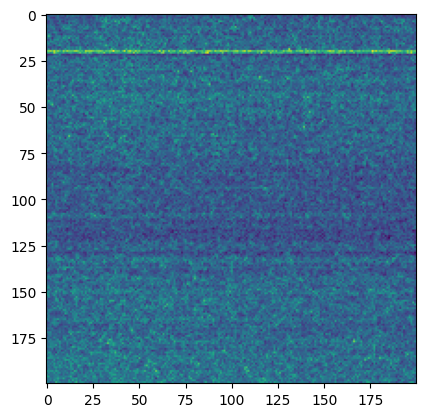

In [116]:
plt.figure()
plt.imshow(ims[0])

In [47]:
im_file_path = r'\\claraserv3.dl.ac.uk\CameraImages\2026\3\31\\'
im_file_names = dset.file['Dataset']['step_000']['CLA-FED-DIA-CAM-02'][()]

im_file = h5py.File(im_file_path + im_file_names.decode('utf-8') + '_mask.hdf', 'r')

In [49]:
im_file['Capture000001'][()].shape

(200, 200)

In [20]:
im_file_names.decode('utf-8') 

'CLA-FED-DIA-CAM-02_2026-03-31_14-19-06UTC_50_images'

In [32]:
f = h5py.File(r'\\claraserv3.dl.ac.uk\CameraImages\2026\3\31\CLA-FED-DIA-CAM-02_2026-03-31_14-19-06UTC_50_images_full.hdf' , 'r')

In [75]:
im_file_names = dset.file['Dataset'].keys()


In [132]:
dset.file['Dataset/step_001/Scan Parameters/ManualScan'][()]

1.25